# Dataset analysis

Hero pick counts and win rates across complete parsed matches.

In [40]:
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module

importlib.reload(dataset_module)

DatasetMaker = dataset_module.DatasetMaker
HERO_ALIASES = dataset_module.HERO_ALIASES
HEROES_PATH = dataset_module.HEROES_PATH
normalize_hero_name = dataset_module.normalize_hero_name

In [41]:
HERO_PICK_STATS_QUERY = """
    WITH complete_matches AS (
        SELECT
            m.match_id
        FROM dotabuff_matches m
        JOIN dotabuff_match_players p ON p.match_id = m.match_id
        WHERE
            m.winner_side IN ('radiant', 'dire')
            AND p.side IN ('radiant', 'dire')
            AND p.hero_slug IS NOT NULL
        GROUP BY m.match_id
        HAVING
            COUNT(*) = 10
            AND COUNT(*) FILTER (WHERE p.side = 'radiant') = 5
            AND COUNT(*) FILTER (WHERE p.side = 'dire') = 5
    )
    SELECT
        p.hero_slug,
        COUNT(*)::int AS appearances,
        COUNT(*) FILTER (WHERE p.side = m.winner_side)::int AS wins,
        COUNT(*) FILTER (WHERE p.side = 'radiant')::int AS radiant_picks,
        COUNT(*) FILTER (WHERE p.side = 'dire')::int AS dire_picks,
        COUNT(*) FILTER (WHERE p.side = 'radiant' AND m.winner_side = 'radiant')::int AS radiant_wins,
        COUNT(*) FILTER (WHERE p.side = 'dire' AND m.winner_side = 'dire')::int AS dire_wins
    FROM complete_matches cm
    JOIN dotabuff_matches m ON m.match_id = cm.match_id
    JOIN dotabuff_match_players p ON p.match_id = cm.match_id
    WHERE
        p.side IN ('radiant', 'dire')
        AND p.hero_slug IS NOT NULL
    GROUP BY p.hero_slug
    ORDER BY appearances DESC
"""

In [42]:
def load_hero_name_by_key(path=HEROES_PATH):
    heroes = json.loads(Path(path).read_text(encoding="utf-8"))
    names = {}

    for hero in heroes.values():
        localized_name = hero.get("localized_name")
        internal_name = hero.get("name")
        if not localized_name:
            continue

        names[normalize_hero_name(localized_name)] = localized_name
        if internal_name:
            short_name = internal_name.removeprefix("npc_dota_hero_")
            names[normalize_hero_name(short_name)] = localized_name

    return names


hero_name_by_key = load_hero_name_by_key()


def canonical_hero_key(value):
    key = normalize_hero_name(value)
    return HERO_ALIASES.get(key, key)


def hero_display_name(canonical_key):
    return hero_name_by_key.get(canonical_key, canonical_key)

In [43]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    with dataset._conn.cursor() as cur:
        cur.execute(HERO_PICK_STATS_QUERY)
        rows = cur.fetchall()

raw_stats = pd.DataFrame(rows)
raw_stats.head(), raw_stats.shape

(  hero_slug  appearances  wins  radiant_picks  dire_picks  radiant_wins  \
 0    jakiro         1146   553            553         593           277   
 1      tusk         1063   505            552         511           272   
 2      tiny          953   466            471         482           239   
 3  hoodwink          945   494            454         491           234   
 4      puck          884   411            430         454           195   
 
    dire_wins  
 0        276  
 1        233  
 2        227  
 3        260  
 4        216  ,
 (127, 7))

In [44]:
stats = raw_stats.copy()
stats["hero_key"] = stats["hero_slug"].map(canonical_hero_key)

hero_stats = (
    stats.groupby("hero_key", as_index=False)[
        ["appearances", "wins", "radiant_picks", "dire_picks", "radiant_wins", "dire_wins"]
    ]
    .sum()
    .assign(
        hero=lambda df: df["hero_key"].map(hero_display_name),
        win_rate=lambda df: df["wins"] / df["appearances"],
        radiant_win_rate=lambda df: df["radiant_wins"] / df["radiant_picks"].where(df["radiant_picks"] > 0),
        dire_win_rate=lambda df: df["dire_wins"] / df["dire_picks"].where(df["dire_picks"] > 0),
    )
    .sort_values(["appearances", "win_rate"], ascending=[False, False])
)

hero_stats = hero_stats[
    [
        "hero",
        "hero_key",
        "appearances",
        "wins",
        "win_rate",
        "radiant_picks",
        "radiant_wins",
        "radiant_win_rate",
        "dire_picks",
        "dire_wins",
        "dire_win_rate",
    ]
]

hero_stats.head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
42,Jakiro,jakiro,1146,553,0.482548,553,277,0.500904,593,276,0.465430
111,Tusk,tusk,1063,505,0.475071,552,272,0.492754,511,233,0.455969
108,Tiny,tiny,953,466,0.488982,471,239,0.507431,482,227,0.470954
38,Hoodwink,hoodwink,945,494,0.522751,454,234,0.515419,491,260,0.529532
80,Puck,puck,884,411,0.464932,430,195,0.453488,454,216,0.475771
32,Ember Spirit,emberspirit,859,442,0.514552,434,220,0.506912,425,222,0.522353
120,Warlock,warlock,819,394,0.481074,399,189,0.473684,420,205,0.488095
75,Pangolier,pangolier,813,393,0.483395,388,201,0.518041,425,192,0.451765
100,Storm Spirit,stormspirit,813,388,0.477245,404,201,0.497525,409,187,0.457213
59,Mars,mars,789,362,0.458809,407,187,0.459459,382,175,0.458115


In [45]:
hero_stats.tail(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
54,Lone Druid,lonedruid,154,95,0.616883,67,43,0.641791,87,52,0.597701
68,Necrophos,necrophos,154,72,0.467532,71,39,0.549296,83,33,0.397590
73,Oracle,oracle,152,83,0.546053,81,45,0.555556,71,38,0.535211
50,Lich,lich,149,69,0.463087,78,40,0.512821,71,29,0.408451
48,Legion Commander,legioncommander,141,73,0.517730,64,33,0.515625,77,40,0.519481
77,Phantom Lancer,phantomlancer,130,50,0.384615,53,23,0.433962,77,27,0.350649
30,Earth Spirit,earthspirit,128,65,0.507812,67,33,0.492537,61,32,0.524590
41,Io,io,127,63,0.496063,70,41,0.585714,57,22,0.385965
123,Winter Wyvern,winterwyvern,118,58,0.491525,53,32,0.603774,65,26,0.400000
85,Riki,riki,113,52,0.460177,59,28,0.474576,54,24,0.444444


In [46]:
summary = {
    "unique_raw_hero_slugs": raw_stats["hero_slug"].nunique(),
    "unique_canonical_heroes": hero_stats["hero_key"].nunique(),
    "total_hero_appearances": int(hero_stats["appearances"].sum()),
    "complete_matches": int(hero_stats["appearances"].sum() / 10),
}

summary

{'unique_raw_hero_slugs': 127,
 'unique_canonical_heroes': 127,
 'total_hero_appearances': 48680,
 'complete_matches': 4868}

In [47]:
MIN_APPEARANCES = 0

popular_heroes = hero_stats[hero_stats["appearances"] >= MIN_APPEARANCES]
popular_heroes.sort_values("win_rate", ascending=False).head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
115,Vengeful Spirit,vengefulspirit,107,67,0.626168,55,37,0.672727,52,30,0.576923
54,Lone Druid,lonedruid,154,95,0.616883,67,43,0.641791,87,52,0.597701
4,Arc Warden,arcwarden,48,29,0.604167,26,15,0.576923,22,14,0.636364
13,Broodmother,broodmother,112,67,0.598214,58,37,0.637931,54,30,0.555556
61,Meepo,meepo,77,46,0.597403,42,28,0.666667,35,18,0.514286
126,Zeus,zeus,184,109,0.592391,92,62,0.673913,92,47,0.510870
109,Treant Protector,treantprotector,261,153,0.586207,122,74,0.606557,139,79,0.568345
47,Largo,largo,273,160,0.586081,116,66,0.568966,157,94,0.598726
95,Slark,slark,273,158,0.578755,122,73,0.598361,151,85,0.562914
66,Naga Siren,nagasiren,286,164,0.573427,122,68,0.557377,164,96,0.585366


In [48]:
popular_heroes.sort_values("win_rate", ascending=True).head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
74,Outworld Devourer,outworlddevourer,73,20,0.273973,42,12,0.285714,31,8,0.258065
55,Luna,luna,238,89,0.373950,127,51,0.401575,111,38,0.342342
77,Phantom Lancer,phantomlancer,130,50,0.384615,53,23,0.433962,77,27,0.350649
52,Lina,lina,200,83,0.415000,101,49,0.485149,99,34,0.343434
22,Dawnbreaker,dawnbreaker,378,160,0.423280,202,82,0.405941,176,78,0.443182
18,Clockwerk,clockwerk,387,175,0.452196,184,79,0.429348,203,96,0.472906
11,Brewmaster,brewmaster,305,139,0.455738,163,71,0.435583,142,68,0.478873
93,Skywrath Mage,skywrathmage,305,139,0.455738,149,67,0.449664,156,72,0.461538
59,Mars,mars,789,362,0.458809,407,187,0.459459,382,175,0.458115
121,Weaver,weaver,316,145,0.458861,157,80,0.509554,159,65,0.408805


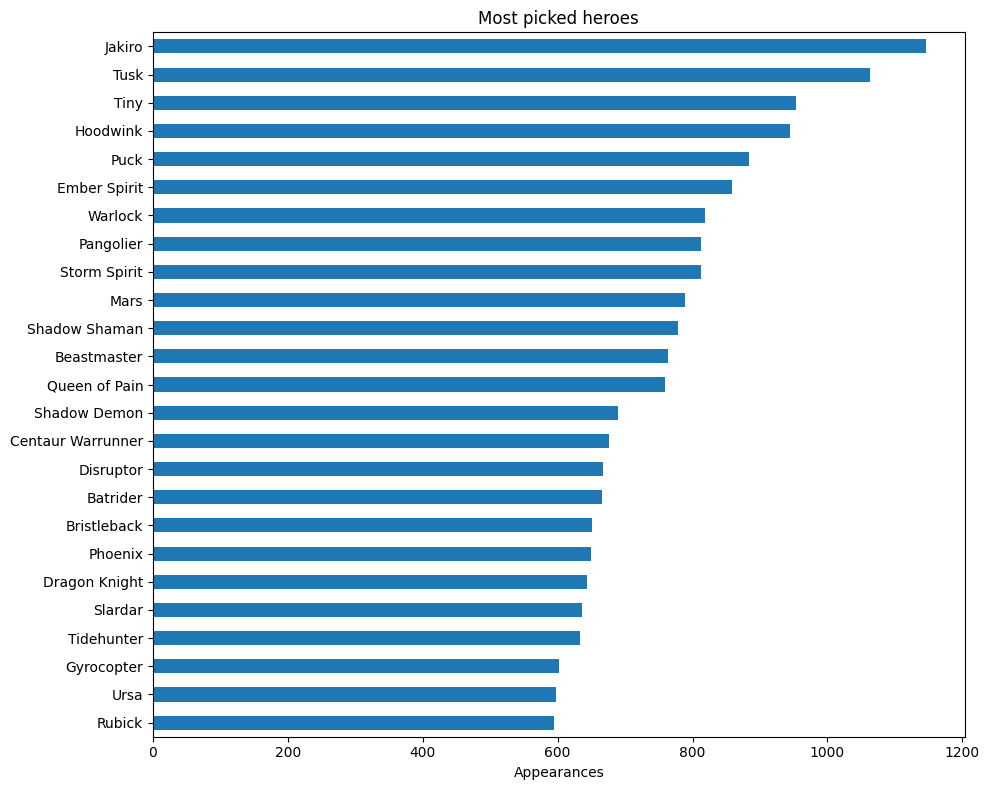

In [49]:
top_picked = hero_stats.sort_values("appearances", ascending=False).head(25).sort_values("appearances")

ax = top_picked.plot.barh(x="hero", y="appearances", figsize=(10, 8), legend=False)
ax.set_title("Most picked heroes")
ax.set_xlabel("Appearances")
ax.set_ylabel("")
plt.tight_layout()

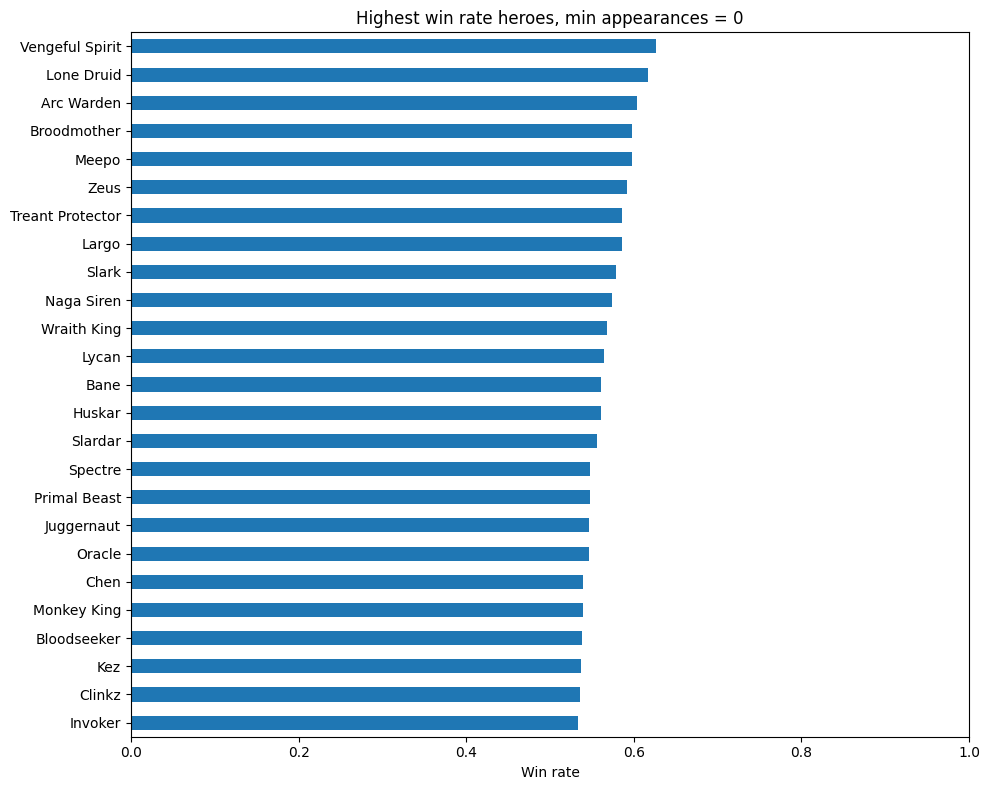

In [50]:
top_win_rate = popular_heroes.sort_values("win_rate", ascending=False).head(25).sort_values("win_rate")

ax = top_win_rate.plot.barh(x="hero", y="win_rate", figsize=(10, 8), legend=False)
ax.set_title(f"Highest win rate heroes, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()

## Histograms

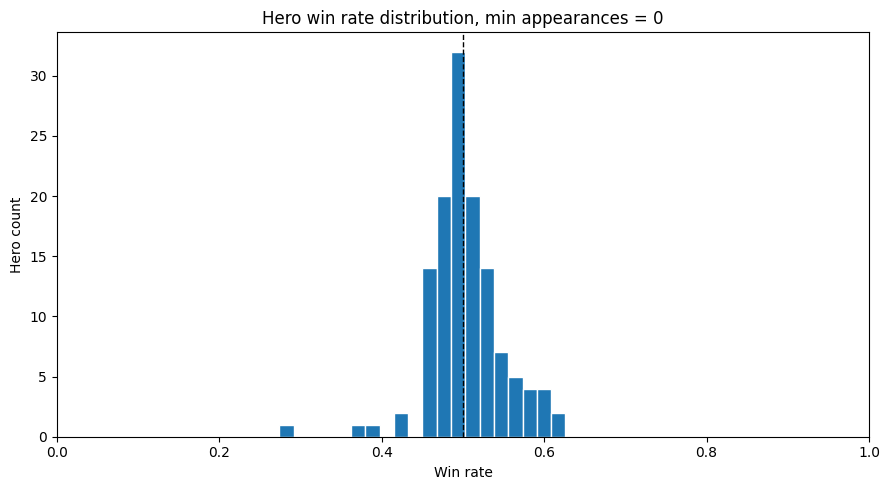

In [51]:
ax = popular_heroes["win_rate"].plot.hist(bins=20, figsize=(9, 5), edgecolor="white")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Hero win rate distribution, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("Hero count")
ax.set_xlim(0, 1)
plt.tight_layout()

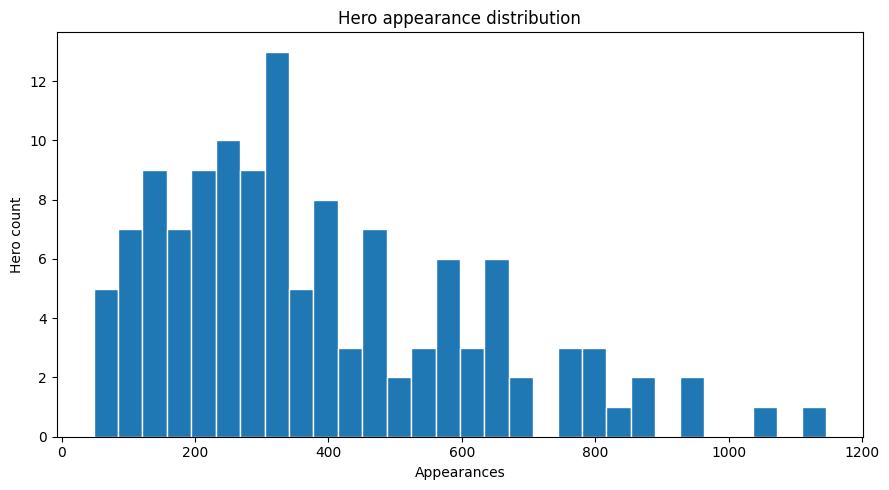

In [52]:
ax = hero_stats["appearances"].plot.hist(bins=30, figsize=(9, 5), edgecolor="white")
ax.set_title("Hero appearance distribution")
ax.set_xlabel("Appearances")
ax.set_ylabel("Hero count")
plt.tight_layout()